In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import os


def detecteer_transducer_hoog(t, ABP, CVP, fs=100):
    """
    Detecteert transducer hoog artefacten volgens de beschreven MATLAB-logica:
    - ABP: dalen onder mean(ABP) - 20
    - CVP: dalen onder mean(CVP) - 10
    - smoothing met moving average (window = 11 = [5 5])
    - begin/eind marge van 30 samples (0.3 s bij fs=100)
    - alleen output als ABP en CVP intervallen overlappen

    Output:
        pandas DataFrame met:
        ['Starttijd', 'Eindtijd', 'Naam van het artefact', 'Signaal']
    """

    def detecteer_per_signaal(signaal, threshold_offset, signaalnaam):
        smooth = (
            pd.Series(signaal)
            .rolling(window=10, center=True)
            .mean()
            .bfill()
            .ffill()
            .values
        )

        # Threshold bepalen
        threshold = np.mean(signaal) - threshold_offset

        # Dalen zoeken via negatieve pieken
        peak_indices, _ = find_peaks(-smooth, height=-threshold)

        artefacten = []

        if len(peak_indices) > 0:
            first_idx = max(0, peak_indices[0] - 30)
            last_idx = min(len(t) - 1, peak_indices[-1] + 30)

            starttijd = round(float(t[first_idx]), 2)
            eindtijd = round(float(t[last_idx]), 2)

            artefacten.append([
                starttijd,
                eindtijd,
                "Transducer Hoog",
                signaalnaam
            ])

        return artefacten

    # --------------------------
    # Detectie per signaal
    # --------------------------
    artefacten_abp = detecteer_per_signaal(signaal=ABP, threshold_offset=20, signaalnaam="ABP")

    artefacten_cvp = detecteer_per_signaal(signaal=CVP, threshold_offset=10, signaalnaam="CVP")

    artefacten = pd.DataFrame(
        artefacten_abp + artefacten_cvp,
        columns=[
            "Starttijd",
            "Eindtijd",
            "Naam van het artefact",
            "Signaal"
        ])

    # --------------------------
    # Alleen overlap behouden
    # --------------------------
    overlappende_indices = []

    tijden = artefacten[["Starttijd", "Eindtijd"]].values

    for i in range(len(tijden)):
        start_tijd = tijden[i, 0]
        eind_tijd = tijden[i, 1]

        overlapping = False

        for j in range(len(tijden)):
            if j != i:
                start_andere = tijden[j, 0]
                eind_andere = tijden[j, 1]

                if not (start_tijd > eind_andere or eind_tijd < start_andere):
                    overlapping = True
                    break

        if overlapping:
            overlappende_indices.append(i)

    artefacten_uit_transducer = artefacten.iloc[overlappende_indices].reset_index(drop=True)

    return artefacten_uit_transducer

In [49]:
import matplotlib.pyplot as plt
'''
Model with function to load artefact data from Excel .xls and .xlsx files and splits 
data in separate vectors to process. Written for KT3401 - Assignment Artefact Detection

'''

def read_Artefacts(path, folder, filename, fs):
    """
    Inputs: 
    path: string to the path with data folders
    folder: string with the name of the folder with the dataset
    filename: string with name of the file, incl. extension
    fs: sampling rate (in Hz)

    Outputs: 
    t: time vector based on length of signal (to use instead of Time)
    ABP, CVP: vectors of arterial blood pressure and central venous pressure, with same length as t
    """
    filepath = os.path.join(path, folder, filename)
    print(f"Attempting to read file at: {filepath}")  # Debug print statement
    
    # Read the Excel file
    try:
        raw = pd.read_excel(filepath, sheet_name=0, header=None)
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None, None, None
    
    raw = pd.read_excel(filepath, sheet_name=0, header=None)
    
    # Skip the first two rows
    raw = raw.iloc[2:, :]
    
    # Convert the data to a numpy array
    data = raw.to_numpy()
    
    # Allocate imported array to column variable names
    ABP = pd.to_numeric(data[:, 1], errors = 'coerce')
    CVP = pd.to_numeric(data[:, 2], errors = 'coerce')
    
    # Create time vector
    t = np.arange(1/fs, len(ABP)/fs + 1/fs, 1/fs)

    return t, ABP, CVP


if __name__ == "__main__":

# Load data
    path = r"C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025"
    folder = "Transducer_hoog"
    filename = r"D05Transd_hoog.xlsx"
    fs = 100

    t, ABP, CVP = read_Artefacts(path, folder, filename, fs)




Attempting to read file at: C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025\Transducer_hoog\D05Transd_hoog.xlsx


In [50]:

def plot_artefacten(t, ABP, CVP, df):
    plt.figure(figsize=(12, 6))
    
    plt.plot(t, ABP, label="ABP")
    plt.plot(t, CVP, label="CVP")

    for _, row in df.iterrows():
        start = row["Starttijd"]
        eind = row["Eindtijd"]

        plt.axvspan(start, eind, color='red', alpha=0.3)

    plt.xlabel("Tijd (s)")
    plt.ylabel("mmHg")
    plt.title("Transducer Hoog Detectie")
    plt.legend()
    plt.show()


In [51]:
resultaat = detecteer_transducer_hoog(t, ABP, CVP, fs=100)

print("\nGedetecteerde artefacten:")
print(resultaat)


Gedetecteerde artefacten:
   Starttijd  Eindtijd Naam van het artefact Signaal
0      24.53     66.35       Transducer Hoog     ABP
1      25.54     66.43       Transducer Hoog     CVP


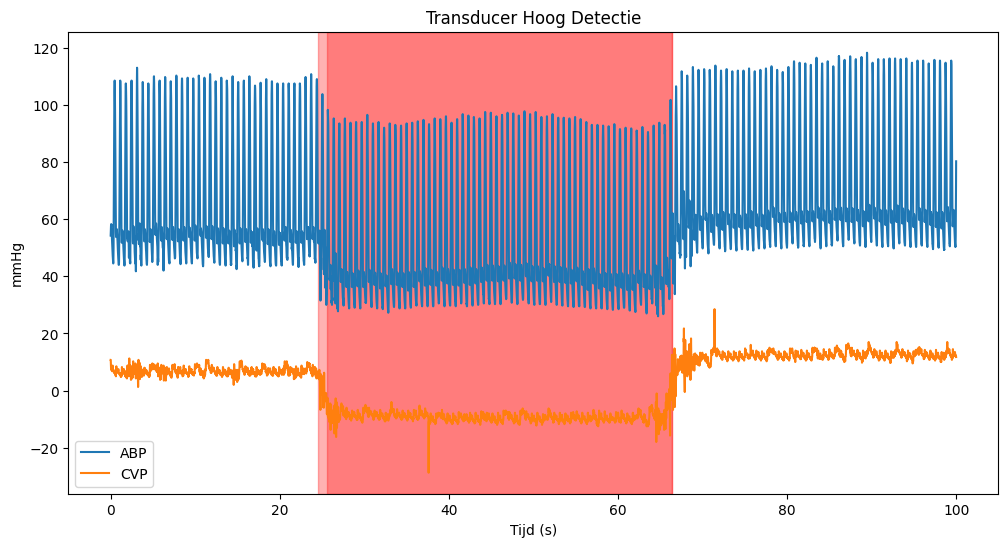

In [52]:
plot_artefacten(t, ABP, CVP, resultaat)